# 💎 Predicción de Precio de Diamantes — KNN Regresivo

Replicamos el mismo pipeline del notebook OLS, pero usando **K-Nearest Neighbors (KNN) como regresor**.  


### Distancia Euclidiana

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Función para calcular la distancia euclidiana entre dos puntos
def distancia_euclidiana(punto1, punto2):
    """
    Calcula la distancia euclidiana entre dos puntos.

    Parameters
    ----------
    punto1 : array-like
        Vector con los valores del primer punto.
    punto2 : array-like
        Vector con los valores del segundo punto.

    Returns
    -------
    dist : float
        Distancia euclidiana entre los dos puntos.
    """
    return np.sqrt(np.sum((punto1 - punto2) ** 2))

# --- Dos diamantes con variables de escalas MUY distintas ---
# Variables: [carat, price]
# Diamante A: 0.5 ct, $1,500  |  Diamante B: 0.6 ct, $3,500
diamante_A = np.array([0.5, 1500])
diamante_B = np.array([0.6, 3500])

dist_sin_escalar = distancia_euclidiana(diamante_A, diamante_B)
print("Sin escalar:")
print(f"  Diamante A: carat={diamante_A[0]}, price=${diamante_A[1]}")
print(f"  Diamante B: carat={diamante_B[0]}, price=${diamante_B[1]}")
print(f"  Diferencia en carat: {abs(diamante_B[0]-diamante_A[0]):.1f}")
print(f"  Diferencia en price: ${abs(diamante_B[1]-diamante_A[1]):,.0f}")
print(f"  → Distancia euclidiana: {dist_sin_escalar:.2f}")
print(f"  ⚠️  price domina la distancia casi por completo\n")

# --- Con StandardScaler ---
datos = np.array([diamante_A, diamante_B])
scaler = StandardScaler()
datos_scaled = scaler.fit_transform(datos)

diamante_A_scaled = datos_scaled[0]
diamante_B_scaled = datos_scaled[1]

dist_escalada = distancia_euclidiana(diamante_A_scaled, diamante_B_scaled)
print("Con StandardScaler:")
print(f"  Diamante A escalado: {diamante_A_scaled}")
print(f"  Diamante B escalado: {diamante_B_scaled}")
print(f"  → Distancia euclidiana: {dist_escalada:.2f}")
print(f"  ✅ Ambas variables contribuyen por igual")


Sin escalar:
  Diamante A: carat=0.5, price=$1500.0
  Diamante B: carat=0.6, price=$3500.0
  Diferencia en carat: 0.1
  Diferencia en price: $2,000
  → Distancia euclidiana: 2000.00
  ⚠️  price domina la distancia casi por completo

Con StandardScaler:
  Diamante A escalado: [-1. -1.]
  Diamante B escalado: [1. 1.]
  → Distancia euclidiana: 2.83
  ✅ Ambas variables contribuyen por igual


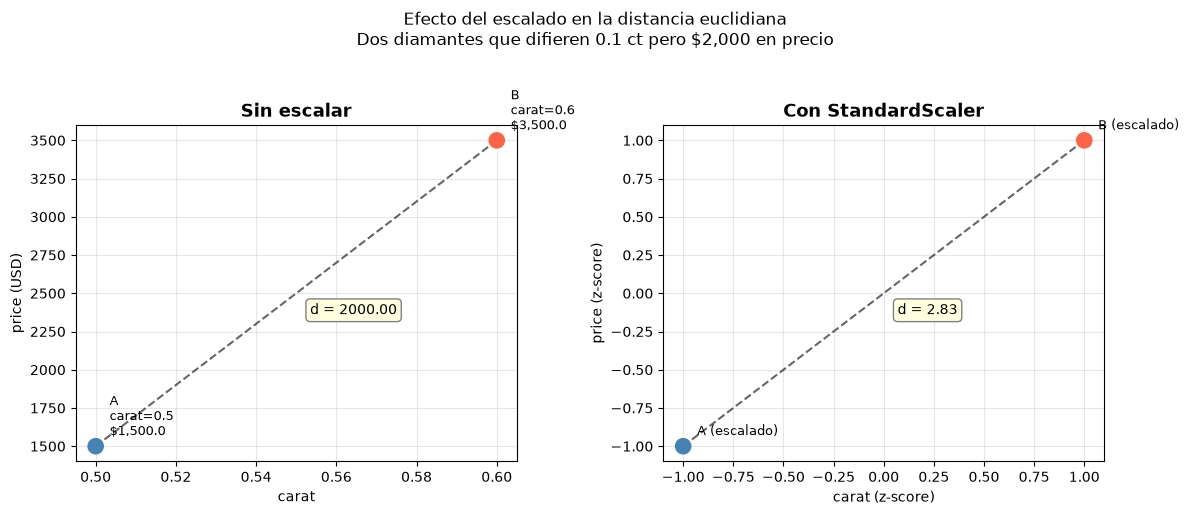

In [2]:
# Visualización: sin escalar vs escalado — side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

puntos = [diamante_A, diamante_B]
puntos_scaled = [diamante_A_scaled, diamante_B_scaled]
labels_raw    = [f'A\ncarat={diamante_A[0]}\n${diamante_A[1]:,}',
                 f'B\ncarat={diamante_B[0]}\n${diamante_B[1]:,}']
labels_scaled = ['A (escalado)', 'B (escalado)']

for ax, pts, labs, titulo, dist, xlabel, ylabel in [
    (axes[0], puntos,        labels_raw,    'Sin escalar',         dist_sin_escalar, 'carat', 'price (USD)'),
    (axes[1], puntos_scaled, labels_scaled, 'Con StandardScaler',  dist_escalada,    'carat (z-score)', 'price (z-score)')
]:
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]

    ax.scatter(xs, ys, color=['steelblue', 'tomato'], s=120, zorder=5)
    ax.plot(xs, ys, 'k--', alpha=0.6)

    for (x, y, lab) in zip(xs, ys, labs):
        ax.annotate(lab, (x, y), textcoords='offset points',
                    xytext=(10, 8), fontsize=9)

    mid_x = (xs[0] + xs[1]) / 2
    mid_y = (ys[0] + ys[1]) / 2
    ax.annotate(f'd = {dist:.2f}', (mid_x, mid_y),
                textcoords='offset points', xytext=(10, -15),
                fontsize=10, color='black',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

plt.suptitle('Efecto del escalado en la distancia euclidiana\n'
             'Dos diamantes que difieren 0.1 ct pero $2,000 en precio',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [3]:
import requests, sqlite3, pandas as pd

url = "https://raw.githubusercontent.com/davidjamesknight/SQLite_databases_for_learning_data_science/main/diamonds.db"
r = requests.get(url)

with open("diamonds.db", "wb") as f:
    f.write(r.content)

conn = sqlite3.connect("diamonds.db")

query = """
SELECT
  O.carat,
  O.price,
  O.depth,
  "O"."table",
  O.x,
  O.y,
  O.z,
  C.cut,
  Co.color,
  Cl.clarity
FROM
  Observation AS O
JOIN
  Cut AS C ON O.cut_id = C.cut_id
JOIN
  Color AS Co ON O.color_id = Co.color_id
JOIN
  Clarity AS Cl ON O.clarity_id = Cl.clarity_id
"""

df = pd.read_sql_query(query, conn)
df.head()

,carat,price,depth,table,x,y,z,cut,color,clarity
0,0.23,326,61.5,55.0,3.95,3.98,2.43,Ideal,E,SI2
1,0.21,326,59.8,61.0,3.89,3.84,2.31,Premium,E,SI1
2,0.23,327,56.9,65.0,4.05,4.07,2.31,Good,E,VS1
3,0.29,334,62.4,58.0,4.20,4.23,2.63,Premium,I,VS2
4,0.31,335,63.3,58.0,4.34,4.35,2.75,Good,J,SI2


## 1️⃣ Preprocesamiento

Mismo split que en el notebook OLS: **80% entrenamiento / 20% prueba**, `random_state=42`.


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (43152, 9) | Test: (10788, 9)


### Encoding y Escalado

KNN calcula **distancias entre puntos** — si una variable tiene valores en miles (precio) y otra en decimales (carat), la primera domina el cálculo de distancia y las demás pierden peso.

Por eso el preprocesamiento para KNN tiene **dos pasos obligatorios** que en OLS eran opcionales:

1. **OrdinalEncoder** — igual que antes, para convertir `cut`, `color`, `clarity` a números respetando su orden
2. **StandardScaler** — escala todas las variables a media 0 y desviación estándar 1, para que ninguna domine la distancia

> ⚠️ En OLS el escalado no afecta las predicciones (solo cambia la interpretación de los coeficientes).  
> En KNN el escalado es **obligatorio** — sin él el modelo aprende distancias distorsionadas.


In [5]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# --- Encoding ordinal (mismo orden que en el notebook OLS) ---
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

enc = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
cat_cols = ['cut', 'color', 'clarity']

X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

X_train_enc[cat_cols] = enc.fit_transform(X_train[cat_cols])
X_test_enc[cat_cols]  = enc.transform(X_test[cat_cols])


In [6]:
# --- Escalado (fit solo en train) ---

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

## 2️⃣ Selección de K — Búsqueda por Validación Cruzada

KNN tiene un **hiperparámetro crítico**: `k` (número de vecinos).

- `k` pequeño → modelo muy sensible al ruido (sobreajuste)
- `k` grande → modelo demasiado suavizado (subajuste)

Probamos un rango de valores de `k` usando **cross-validation de 5 folds** sobre el conjunto de entrenamiento y elegimos el que minimiza el RMSE de CV.


In [7]:
import plotly.graph_objects as go
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

k_values = range(2, 31)
rmse_cv = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    # Hacer cross_validation
    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    rmse_cv.append(-scores.mean())

best_k = k_values[np.argmin(rmse_cv)]
best_rmse = min(rmse_cv)

print("Mejor Número de K: ", best_k)
print("Mejor Puntuación: ", best_rmse)

# --- Gráfica ---

Mejor Número de K:  7
Mejor Puntuación:  735.2678708635135


In [8]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=list(k_values),
        y=rmse_cv,
        mode='lines+markers',
        name='RMSE CV',
        line=dict(color='steelblue')
    )
)

fig.show()

## 3️⃣ Ajuste del Modelo KNN con el mejor k

Entrenamos el KNN final con el `k` óptimo encontrado por CV.


In [9]:
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
knn_final

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


## 4️⃣ Evaluación en Test

Calculamos R², RMSE y MAPE sobre el conjunto de test — exactamente las mismas métricas que en el notebook OLS para poder comparar.


In [10]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from math import sqrt

y_pred_knn = knn_final.predict(X_test_scaled)

r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = sqrt(mean_squared_error(y_test, y_pred_knn))
mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn) * 100

print("R2 en test: ", r2_knn)
print("RMSE en test: ", rmse_knn)
print("MAPE en test: ", mape_knn)

R2 en test:  0.9682837644646914
RMSE en test:  710.0614997385051
MAPE en test:  10.258164898735773


## 5️⃣ Real vs Predicho

Un buen modelo debe tener los puntos alineados sobre la diagonal `y = x`.  
Desviaciones sistemáticas revelan sesgos del modelo.


In [11]:
import plotly.express as px